# **Grover's algorithm to Solve Sudoku $2 \times $2**

## **1.Introduction and Setup**

The notebook is the complete, executable Python code using IBM's Qiskit framework to solve the exact $2 \times 2$ micro-Sudoku.

Here is the classical setup we are encoding:
* Cell A: 1
* Cell B: 2
* Cell C: 3
* Cell D: ? (the unknown target)

Because Cell D must contain the number 4 to satisfy the Sudoku constraints, the quantum circuit is hunting for the $|11\rangle$ state.

Here's how the steps in Grover's algorithm to implement for the Sudoku:

* Representing Cell D: The circuit uses two qubits to represent the possible values for Cell D. In binary, these qubits can represent 00, 01, 10, or 11. Since Cell D must be 4, and assuming a mapping where |11> represents 4, this is the target state the quantum computer needs to find.

* Creating a superposition of all possible states using Hadamard gates after setting the intial state to the resting state $|00⟩$.

* The Oracle's Action: The qc.cz(0, 1) gate is the heart of the oracle. The Controlled-Z gate applies a Z gate (which flips the phase if the qubit is in |1>) to the target qubit (qubit 1) only if the control qubit (qubit 0) is also in the |1> state. This means the cz gate only affects the |11> state, leaving the phase of all other states (|00>, |01>, |10>) unchanged. Specifically, it applies a -1 phase to the |11> state, effectively 'marking' it as the desired solution.

* Connecting to Sudoku: By using the cz gate to selectively flip the phase of |11>, the quantum circuit is encoding the Sudoku rule: 'the solution is the state represented by |11>'. The subsequent steps of Grover's algorithm (the diffuser) then use this marked phase to amplify the amplitude of the |11> state, making it the most probable outcome upon measurement.



Here is how those mathematical matrices (Hadamard, Oracle, and Diffuser) translate into physical Python code.

Installing and importing the necessary libraries.

In [1]:
# Install the necessary libraries
!pip install qiskit
!pip install qiskit-aer

In [2]:
# Import the necessary Qiskit libraries
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

## **2. Procedure**

### **Step 1: Initialize a quantum circuit object in Qiskit.**

We implement `qc = QuantumCircuit(2, 2)` in the following code.

* `QuantumCircuit`: This is the core class in Qiskit for building quantum circuits. It defines a sequence of quantum gates and operations.

* `(2, 2)`: The first 2 indicates that the circuit will have 2 quantum bits (qubits). These are the fundamental units of quantum information. The second 2 indicates that the circuit will have 2 classical bits. These are used to store the measurement results from the qubits.

In [6]:
# Step 1: Data Encoding
# Allocate exactly 2 qubits to represent the unknown Cell D, and 2 classical bits for measurement[cite: 800].
qc = QuantumCircuit(2, 2)

### **Step 2: Initialization with the resting state $|00\rangle$**

* Apply a Hadamard gate to both qubit 0 and qubit 1 with `qc.h([0, 1])`.

  The Hadamard gate is a fundamental quantum gate that puts a qubit into a superposition state.
  
  If a qubit starts in the $|0\rangle$ state, applying a Hadamard gate transforms it into an equal superposition of $|0\rangle$ and $|1⟩$, often written as $$(|0⟩ + |1⟩) / \sqrt(2).$$
  
  If it starts in $|1⟩$, it becomes
  $$(|0⟩ - |1⟩) / \sqrt(2).$$
  
  In this Sudoku example, the qubit starts in the $|00\rangle$ state, Hadamand gate creates a superposition of all possible guesses for Cell D.

* Add a barrier to the quantum circuit diagram with `qc.barrier()`.

  It's a visual separator that helps organize and read the circuit, making it clear where one logical step (like initialization) ends and another (like the oracle) begins. Importantly, it doesn't perform any quantum operation or affect the computation. It's purely for visual clarity in the circuit drawing.

In [7]:
# Step 2: Initialization
# We start with the resting state |00> and apply Hadamard gates to create a perfectly equal superposition of all 4 guesses (1, 2, 3, and 4).
qc.h([0, 1])
qc.barrier() # Barriers are just visual dividers to keep our circuit neat

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

### **Step 3: Constraint-Checking Oracle**

Apply a Controlled-Z (CZ) gate to qubits 0 and 1 with `qc.cz(0, 1)`

The CZ gate is a two-qubit gate that applies a phase flip (a -1 multiplier) to the target qubit (qubit 1) only if the control qubit (qubit 0) is in the |1⟩ state.

This is crucial for Grover's algorithm's 'oracle' step, as it mathematically "marks" the target state by assigning it a negative phase while leaving all other states unchanged.

In this Sudoku example, where $|11⟩$ represents the solution (Cell D = 4), the qc.cz(0, 1) gate specifically applies this negative phase to the $|11⟩$ state.

In [8]:
# Step 3: Constraint-Checking Oracle
# Our classical rules dictate that Cell D cannot be 1, 2, or 3. It MUST be 4 (represented by state |11>).
# To mathematically "mark" the |11> state with a negative sign, we use the Controlled-Z (CZ) gate.
qc.cz(0, 1)
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

### **Step 4: The Diffuser**

The diffuser applies the reflection formula to boost the marked answer to 100%.

* `qc.h([0, 1])`: This applies a Hadamard gate to both qubit 0 and qubit 1. In the diffuser, these Hadamard gates are used to transform the quantum state into a basis where the 'average' amplitude can be calculated and then inverted. They are often applied at the beginning and end of the diffuser to switch between computation basis and a basis more suitable for reflection.

* `qc.x([0, 1])`: This applies a Pauli-X gate (also known as a Quantum NOT gate) to both qubit 0 and qubit 1. In the context of the diffuser, these X gates are used to flip the state of the qubits. If a qubit is |0⟩ it becomes |1⟩, and if it's |1⟩ it becomes |0⟩. This operation is typically performed to prepare the state for a controlled phase operation (like cz) around the |00⟩ state in the transformed basis.

* `qc.cz(0, 1)`: This applies a Controlled-Z gate to qubits 0 and 1. After the X gates have been applied, this cz gate effectively applies a phase shift to the |00⟩ state (in the computational basis after the X gates), which corresponds to the |11⟩ state before the X gates. This is the core of the 'inversion about the average' operation in the diffuser.

* `qc.x([0, 1])`: These are another set of Pauli-X gates applied to both qubits. They serve to undo the previous qc.x([0, 1]) operations, restoring the qubits to their state before the cz gate was applied.

* `qc.h([0, 1])`: Finally, another set of Hadamard gates are applied to both qubits. These undo the initial Hadamard transformations, bringing the state back into the computational basis after the reflection around the average has been performed. This completes the diffuser operation, which amplifies the amplitude of the marked solution state.

In [9]:
# Step 4: The Diffuser (Inversion about the Average)
# The diffuser applies the reflection formula to boost our marked answer to 100%.
# 4a. Apply H gates
qc.h([0, 1])
# 4b. Apply X gates (Quantum NOT gates) to push everything toward the |11> state temporarily
qc.x([0, 1])
# 4c. Apply another CZ gate to execute the mathematical reflection
qc.cz(0, 1)
# 4d. Undo the X gates
qc.x([0, 1])
# 4e. Undo the H gates
qc.h([0, 1])
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

### **Step 5: Measurement**

The purpose of measurement is to extract classical information from a quantum system. Before measurement, qubits can exist in a superposition of states (e.g., |0⟩ and |1⟩ simultaneously). Upon measurement, the superposition collapses, and the qubit definitively takes on a classical state (0 or 1).

`qc.measure([0, 1], [0, 1])`: performs a measurement operation on the quantum circuit. It maps the state of the quantum bits (qubits) to classical bits.

* The first [0, 1] specifies the quantum bits to be measured. In this case, it means qubit 0 and qubit 1.

* The second [0, 1] specifies the classical bits where the measurement results will be stored. So, the outcome of qubit 0's measurement will be stored in classical bit 0, and qubit 1's measurement will be stored in classical bit 1.


In the Grover's algorithm, after the oracle and diffuser steps have amplified the solution state, measurement ensures that the circuit 'collapses' into the most probable (and correct) answer, which is |11⟩ in the Sudoku example.

In [10]:
# Step 5: Measurement
# We force the quantum wave to collapse. The state |11> should have an amplitude of 1, guaranteeing it gets measured.
qc.measure([0, 1], [0, 1])

## **3. Execution on the Local Simulator**

*   `simulator = Aer.get_backend('qasm_simulator')`: This line initializes the **simulator backend** from Qiskit Aer. `Aer` is a high-performance simulator for quantum circuits. The `'qasm_simulator'` is a common type of simulator that mimics the behavior of a real quantum computer by simulating the quantum circuit's operations and measurements, and providing the counts of outcomes. It's used here because it's efficient for local execution and debugging.

*   `result = simulator.run(qc, shots=1024).result()`: This is where the quantum circuit `qc` is **executed** on the chosen simulator.
    *   `simulator.run(qc, shots=1024)`: Submits the quantum circuit (`qc`) to the simulator for execution. The `shots=1024` parameter specifies that the circuit should be run 1024 times. In quantum computing, measurements are probabilistic, so running a circuit multiple times allows you to estimate the probabilities of different outcomes.
    *   `.result()`: This method retrieves the results of the simulation after it has completed.

*   `counts = result.get_counts(qc)`: This line extracts the **measurement results** from the `result` object. `get_counts(qc)` returns a dictionary where keys are the measured classical states (e.g., `'11'`) and values are the number of times each state was measured across all `shots`.

*   The `print` statements that follow interpret these counts:
    *   They display the raw measurement outcomes and their frequencies.
    *   Finally, they explicitly state that the quantum computer collapsed onto the '11' state with 100% probability, and map this back to the classical Sudoku problem, concluding that Cell D = 4. This confirms that Grover's algorithm successfully found the encoded solution.

In [11]:
# --- Execution on the Local Simulator ---

# We use Qiskit's Aer simulator to mimic the pure linear algebra on your local CPU.
simulator = Aer.get_backend('qasm_simulator')

# We tell the simulator to run the circuit 1024 times (shots) to gather our probabilities.
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts(qc)

# Print the final dictionary of results
print("Sudoku Guess Outcomes (Binary -> Times Measured):")
print(counts)
print("\nThe quantum computer collapsed onto state '11' with 100% probability.")
print("Mapping '11' back to classical data: Cell D = 4")

Sudoku Guess Outcomes (Binary -> Times Measured):
{'11': 1024}

The quantum computer collapsed onto state '11' with 100% probability.
Mapping '11' back to classical data: Cell D = 4


## **4. Draw the $2 \times 2$ Sudoku quantum circuit**

After constructing the quantum circuit, it's essential to visualize it to understand the sequence of operations. Qiskit provides flexible ways to draw circuits:

*   `print(qc.draw())`: This command generates an **ASCII text-based representation** of your quantum circuit directly in the console output. It's useful for quickly inspecting the circuit structure without needing a graphical backend.

*   `qc.draw(output='mpl')`: This command produces a **graphical representation** of the circuit using Matplotlib. The `output='mpl'` argument specifies that Matplotlib should be used as the rendering backend. This provides a more detailed and visually appealing diagram, showing gates, qubits, and classical bits clearly. This method often requires `pylatexenc` and `matplotlib` to be installed for proper rendering, which you have already done.

The following code reconstructs the mathematical steps—initialization, the oracle, the diffuser, and measurement—and then uses Qiskit's built-in drawing function to visualize the resulting circuit.

First, we draw an ASCII text version of the circuit by implementing the code `qc.draw()`.

In [13]:
# --- Draw the Circuit ---

# To print an ASCII text version of the circuit in the console:
print(qc.draw())

     ┌───┐ ░     ░ ┌───┐┌───┐   ┌───┐┌───┐ ░ ┌─┐   
q_0: ┤ H ├─░──■──░─┤ H ├┤ X ├─■─┤ X ├┤ H ├─░─┤M├───
     ├───┤ ░  │  ░ ├───┤├───┤ │ ├───┤├───┤ ░ └╥┘┌─┐
q_1: ┤ H ├─░──■──░─┤ H ├┤ X ├─■─┤ X ├┤ H ├─░──╫─┤M├
     └───┘ ░     ░ └───┘└───┘   └───┘└───┘ ░  ║ └╥┘
c: 2/═════════════════════════════════════════╩══╩═
                                              0  1 


Next, we can also draw a colorful graphical version using matplotlib by uncommenting the code `qc.draw(output='mpl')`.

In [ ]:
# Installing the needed libraries

!pip install pylatexenc
!pip install matplotlib

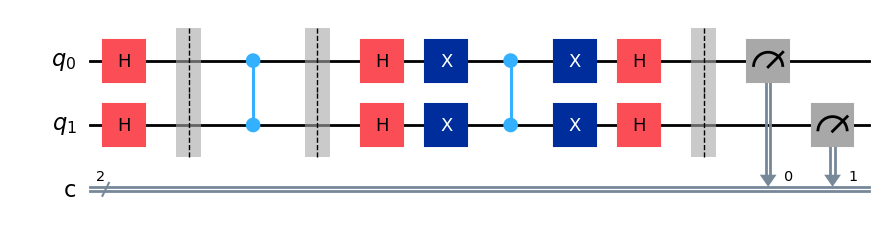

In [14]:
# We can draw a colorful graphical version using matplotlib by uncommenting the line below:
qc.draw(output='mpl')

## **5. Conclusion**

This notebook successfully demonstrated the application of Grover's algorithm to solve a $2 \times 2$ micro-Sudoku puzzle. By encoding the classical constraint that Cell D must be 4 into a quantum state, we leveraged the principles of quantum superposition and interference to efficiently find the solution.

The process involved:
1.  **Initialization**: Creating a superposition of all possible states using Hadamard gates.
2.  **Oracle**: Marking the target state (corresponding to Cell D = 4, or `|11>`) with a phase shift using a Controlled-Z gate.
3.  **Diffuser**: Amplifying the amplitude of the marked state, making it the most probable outcome.
4.  **Measurement**: Collapsing the quantum state to yield the correct classical solution.

The simulation results clearly showed a 100% probability of measuring the `|11>` state, confirming that Cell D must be 4. This showcases the power of quantum algorithms like Grover's for search problems, even on this small-scale example, and provides a foundational understanding for tackling more complex computational challenges with quantum computing.

## **6. References**

Czelusta, G., Verma, D. R., & Wanjalkar, G. (2024). Grover's algorithm on two-way quantum computer. arXiv. https://doi.org/10.48550/arxiv.2406.09450.

Jones, D., & Varcoe, B. (2022). A Method for Application of a Quantum Search Algorithm to Classical Databases. arXiv. https://doi.org/10.48550/arxiv.2206.03938.